# 2. Physical SMBHB model 

This notebook is used to test the photometric model of Super Massive Black Hole Binaries (SMBHBs) consisting of the three components: 
- Stochastic Quasar Variability (Damped Random Walk; DRW)
- Doppler boosting
- Gravitational self-lensing

Last tested with PlatoSim version: `3.7.0-135-g178ce335`

In [2]:
%load_ext autoreload
%autoreload 2
%matplotlib notebook

In [5]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.time import Time
from astropy import units as u
from astropy import constants as c
from pathlib import Path

# PlatoSim libraries
import platosim.utilities as ut
import platosim.plot      as pt
import platosim.smbhb     as smbhb
from platosim.lightcurve   import LightCurve
from platosim.slurm        import workerOverview
from platosim.matplotlibrc import setup_notebook
setup_notebook()

from IPython.display import display, HTML
display(HTML("<style>.container {width:70% !important; }</style>"))

In [6]:
# Paths to where data is stored
path = Path(os.getenv('PLATO_WORKDIR')) / 'smbhb'
fdir = path / 'figures'

In [53]:
tdur = 4 * ut.year() / 86400  # [days]
dt   = 1                      # [days]
time = smbhb.time(tdur, dt)   # [days]

---
## Model Spikey
---

We here verify that we can recreate the synthetic model light curve of Spikey using the constants and parameters from Hu+2020.

In [77]:
M1 = 10**7.4   # [M_sun]
M2 = 10**6.7   # [M_sun]
z     = 0.962
t0    = 1.050  # [yr]
P     = 1.144  # [yr]
i     = 81.95  # [deg]
e     = 0.524  
w     = 84.63  # [deg]
logM  = np.log10(M2 + M1) # [log(M_Sun)]
q     = M2 / M1
L     = 0.89
alpha = 2.09
vz    = 0      # [cm/s]
tau   = 434    # [day] (tau = 434 days for Spikey)
sigma = 3400   # [ppm] (SF_inf=3400 ppm for Spikey)
seed  = 123456789

### Fiducial model

In [82]:
params = smbhb.model_params()
params.z     = z
params.t0    = t0
params.P     = P
params.i     = i
params.e     = e
params.w     = w
params.logM  = logM
params.q     = q
params.L     = L
params.alpha = alpha
params.vz    = vz
params.tau   = tau
params.sigma = sigma  
params.seed  = seed

In [83]:
model = smbhb.model(params)

In [84]:
df = model.light_curve(time, df=True)

<IPython.core.display.Javascript object>


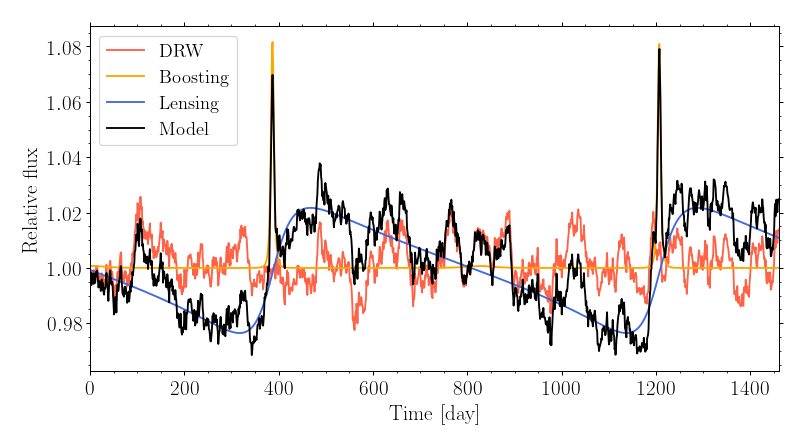

In [85]:
smbhb.plot_model(df); 

### Variation of Argument of Periapse

<IPython.core.display.Javascript object>


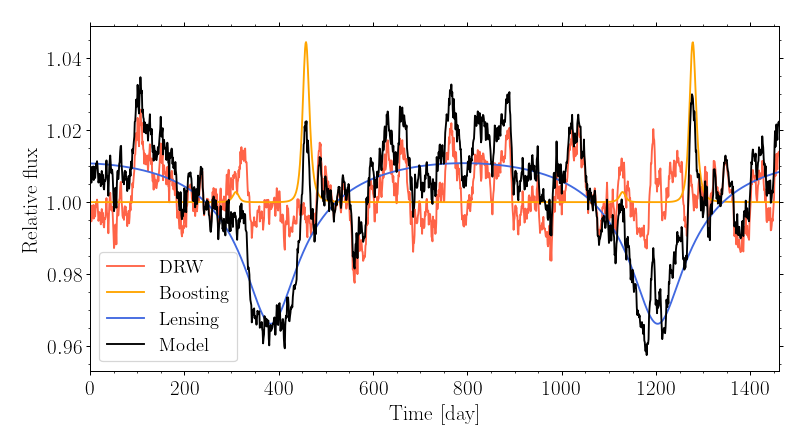

<IPython.core.display.Javascript object>


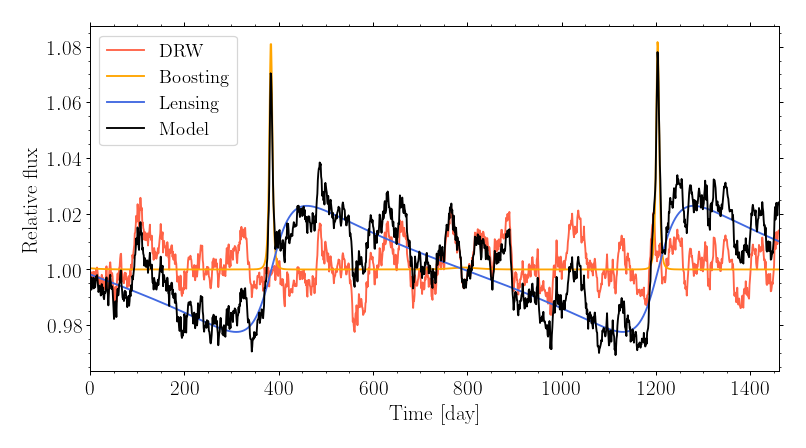

<IPython.core.display.Javascript object>


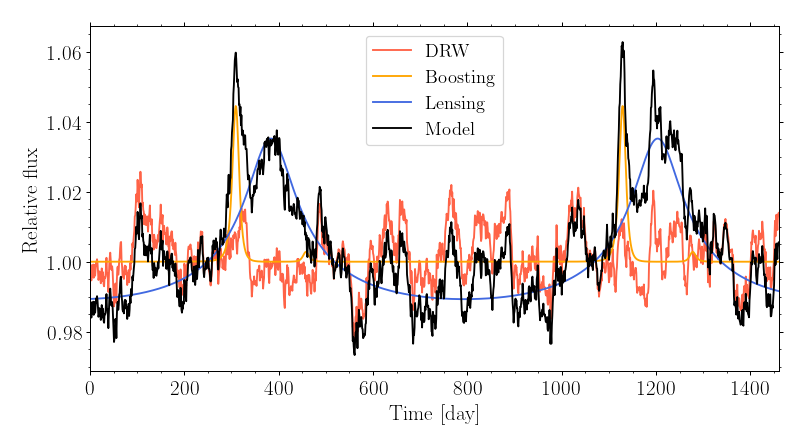

<IPython.core.display.Javascript object>


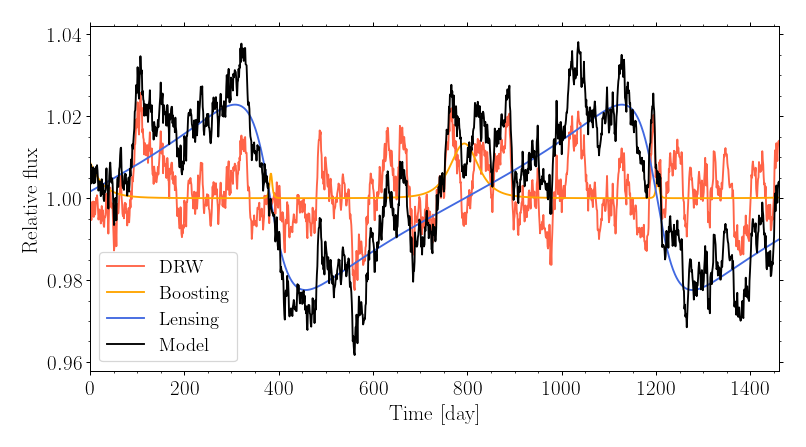

In [86]:
for omega in [0, 90, 180, 270]:
    # Set parameters
    params = smbhb.model_params()
    params.z     = z
    params.t0    = t0
    params.P     = P
    params.i     = i
    params.e     = e
    params.w     = omega
    params.logM  = logM
    params.q     = q
    params.L     = L
    params.alpha = alpha
    params.vz    = vz
    params.tau   = tau
    params.sigma = sigma  
    params.seed  = seed
    # Initialise model with parameters
    model = smbhb.model(params)
    # Generate model and plot
    smbhb.plot_model(model.light_curve(time, df=True)); 

---
## Sanity checks of implemented code
---

### Reproduce D'Orazio & Di Stefano 2018 (Fig. 3)

In [ ]:
params = smbhb.model_params()
params.z     = z
params.t0    = t0
params.P     = P
params.i     = i
params.e     = e
params.w     = w
params.logM  = logM
params.q     = q
params.L     = L
params.alpha = alpha
params.vz    = vz
params.tau   = tau
params.sigma = sigma  
params.seed  = seed

In [120]:
# Initialise model
dt   = 3600
tdur = 8 * ut.year()
time = np.arange(0, tdur, dt) * u.s
model = SMBHB(time, seed=123456789)

# Parameters
t0 = 0 * u.yr
P  = 4 * u.yr
e  = 0
w  = 0 * u.deg 
L  = 0.5
z  = 0
v_z   = 0
alpha = 2.0
M = 1e9 * u.M_sun

# As function of inclination (we define I = 90 - i)
inclinations = [3.5, 7.0, 10.7, 14.4, 89]
colors = ['k', 'orange', 'green', 'blue', 'k']
lines  = ['-', '-', '-', '--', '-.']
phase  = time.to('yr').value / P.value 

<IPython.core.display.Javascript object>


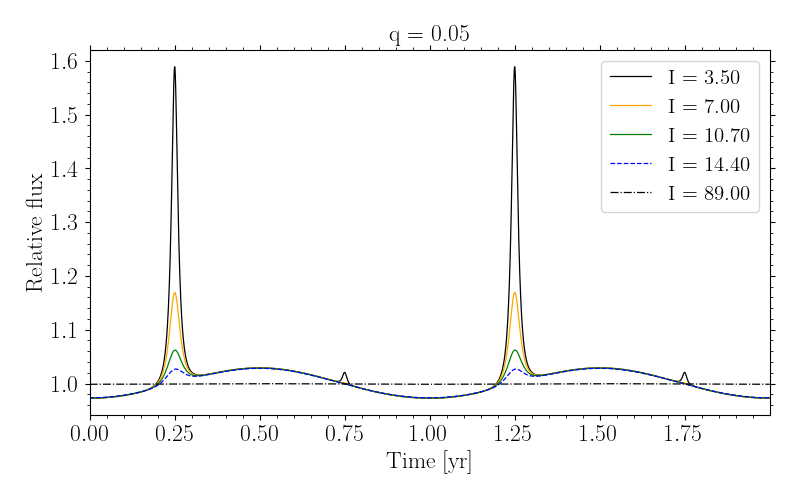

In [121]:
# Left panel plot
q = 0.05
M1 = M / (q + 1)
M2 = M - M1
fig, ax = plt.subplots(1, 1, figsize=(8,5))
for I,c,l in zip(inclinations, colors, lines):
    i = np.deg2rad(90-I) * u.rad
    model.initPhysicalModel(t0, z, P, M1, M2, i, e, w, L)
    model.doppler_boosting(alpha, v_z)
    model.gravitational_lensing(J, wvl)
    flux = model.evalPhysicalModel()
    ax.plot(phase, flux, l, c=c, label=f'I = {I:.2f}', lw=0.9)
ax.set_xlim(0, phase[-1])
ax.set_xlabel(r"Time [yr]")
ax.set_ylabel(r"Relative flux")
ax.set_title(f'q = {q:.2f}')
plt.legend()
plt.tight_layout();

<IPython.core.display.Javascript object>


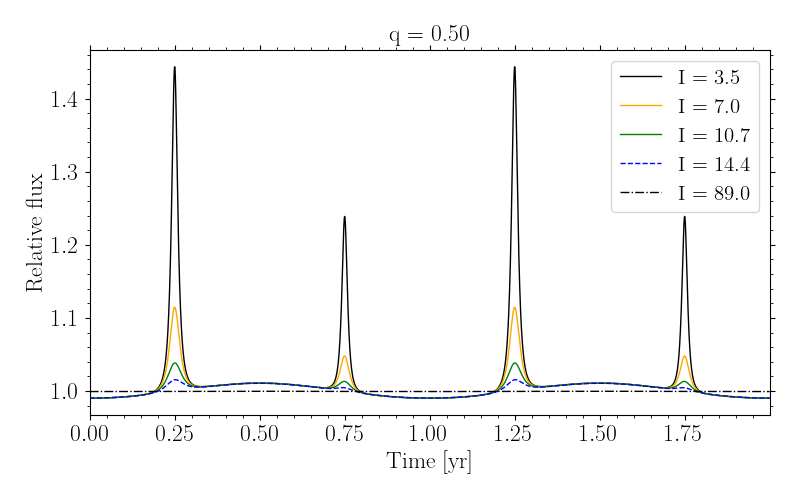

In [122]:
# Right panel plot
q = 0.5
M1 = M / (q + 1)
M2 = M - M1
fig, ax = plt.subplots(1, 1, figsize=(8,5))
for I,c,l in zip(inclinations, colors, lines):
    i = np.deg2rad(90-I) * u.rad
    model.initPhysicalModel(t0, z, P, M1, M2, i, e, w, L)
    model.doppler_boosting(alpha, v_z)
    model.gravitational_lensing(J, wvl)
    flux = model.evalPhysicalModel()
    ax.plot(phase, flux, l, c=c, label=f'I = {I:.1f}', lw=1)
ax.set_xlim(0, phase[-1])
ax.set_xlabel(r"Time [yr]")
ax.set_ylabel(r"Relative flux")
ax.set_title(f'q = {q:.2f}')
plt.legend()
plt.tight_layout();

### Reproduce Hu+2020 (Fig. 4)

In [129]:
# Initialise model
dt   = 3600
tdur = ut.year() * 40
time = np.arange(0, tdur, dt) * u.s
model = SMBHB(time, seed=123456789)

# Parameters
z = 0
t0 = 10 * u.yr
P = 20 * u.yr
M1 = 5e8 * u.M_sun
M2 = 5e7 * u.M_sun
i = 87 * u.deg
L = 0.7
alpha = 2.0
v_z   = 0
J = np.pi/2 * u.rad

# Parameters to loop over
eccens = [0.001, 0.234, 0.467, 0.7]
omegas = [0, 90, 180, 270]
colors = ['orange', 'deeppink', 'purple', 'navy']
phase  = time.to('yr').value / P.to('yr').value

<IPython.core.display.Javascript object>


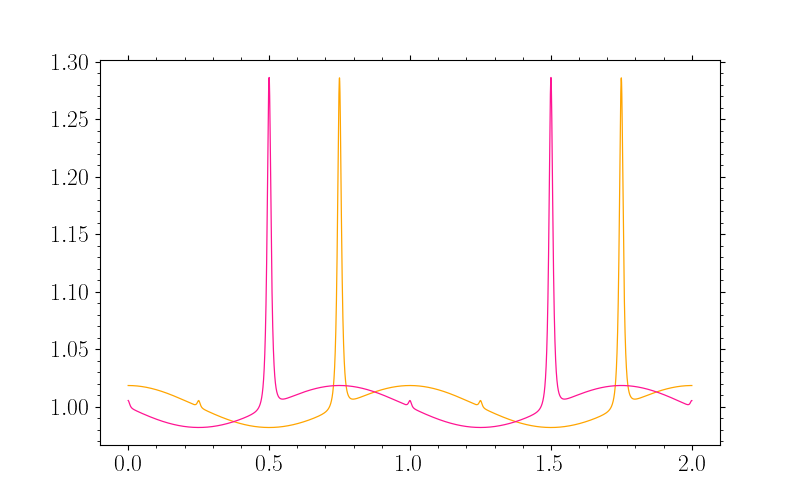

KeyboardInterrupt: 

In [130]:
e = 0.001
fig, ax = plt.subplots(1, 1, figsize=(8,5))
for w,c,l in zip(omegas, colors, labels):
    model.initPhysicalModel(t0, z, P, M1, M2, i, e, w*u.deg, L)
    model.doppler_boosting(alpha, v_z)
    model.gravitational_lensing(J, wvl)
    flux = model.evalPhysicalModel()
    ax.plot(phase, flux, '-', c=c, label=f'w = {w:.0f}', lw=0.9)
ax.set_xlim(0, phase[-1])
ax.set_xlabel(r"Time [yr]")
ax.set_ylabel(r"Relative flux")
ax.set_title(f'e = {e:.3f}')
ax.legend()
plt.tight_layout();
# fig.savefig(fdir / f'model_comparison_Hu+2020fig4.png', bbox_inches='tight', dpi=300)

<IPython.core.display.Javascript object>


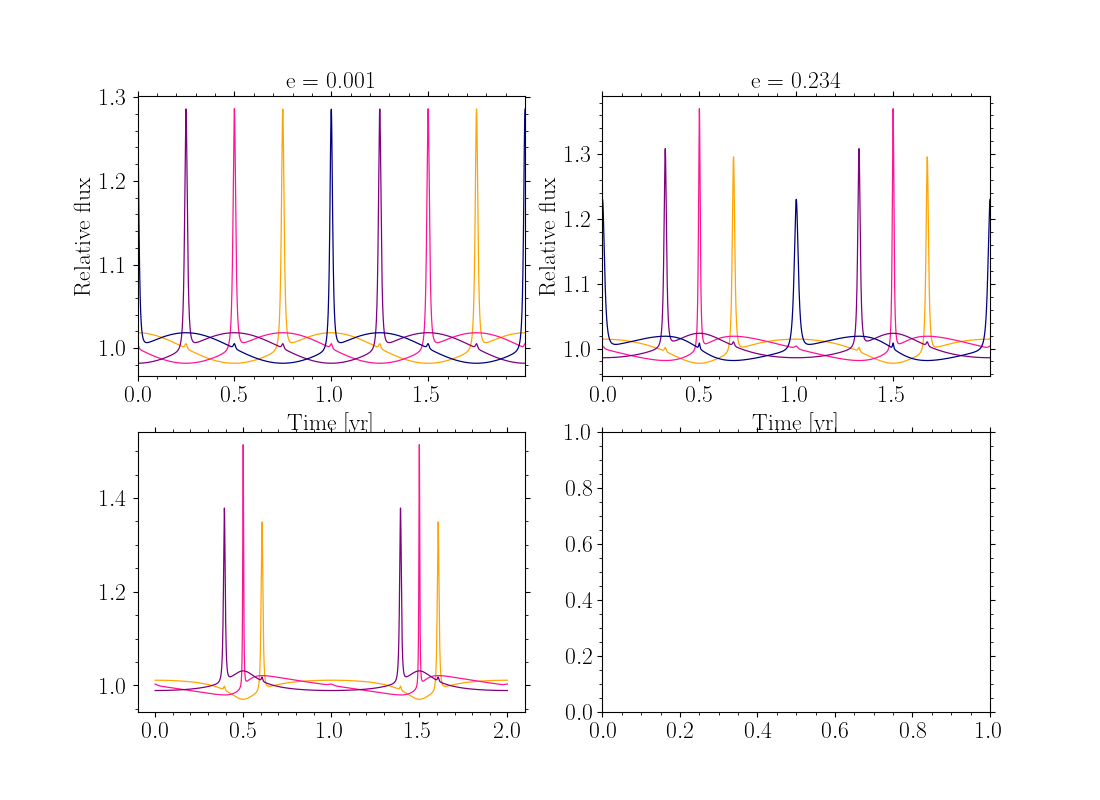

KeyboardInterrupt: 

In [126]:
fig, axes = plt.subplots(2, 2, figsize=(11,8))
for e,ax in zip(eccens, [axes[0,0], axes[0,1], axes[1,0], axes[1,1]]):
    for w,c,l in zip(omegas, colors, labels):
        model.initPhysicalModel(t0, z, P, M1, M2, i, e, w*u.deg, L)
        model.doppler_boosting(alpha, v_z)
        model.gravitational_lensing(J, wvl)
        flux = model.evalPhysicalModel()
        ax.plot(phase, flux, '-', c=c, label=r'\omega ='+f'{w:.0f}', lw=0.9)
    ax.set_xlim(0, 2)
    ax.set_xlabel(r"Phase")
    ax.set_ylabel(r"Relative flux")
    ax.set_title(f'e = {e:.3f}')
plt.legend()
plt.tight_layout();
# fig.savefig(fdir / f'model_comparison_Hu+2020fig4.png', bbox_inches='tight', dpi=300)

---
## Modelling with Binlite
---

Binlite assumes for now a constant q=0.1 values.

In [129]:
import binlite as blt
from binlite import AccretionSeries, BinaryAlphaDisk
from binlite.flux import periodic_flux_series, normalized_flux_series

### Reproduce Fig. 6 with/without accretion

In [191]:
# Parameters stated in Section 4 (Example Lightcurves)
n_orbits = 2
P_yr = 1.0
M_msun = 2 * 1e9
f_edd = 0.1
dl_pc = 1.5 * 1e9  # z~0.29
e = 0.4
omegas_deg = [0, 90, 180, 270]
inclinations_deg = [5, 45, 85]
colors = ['blue', 'orange', 'red']

<IPython.core.display.Javascript object>


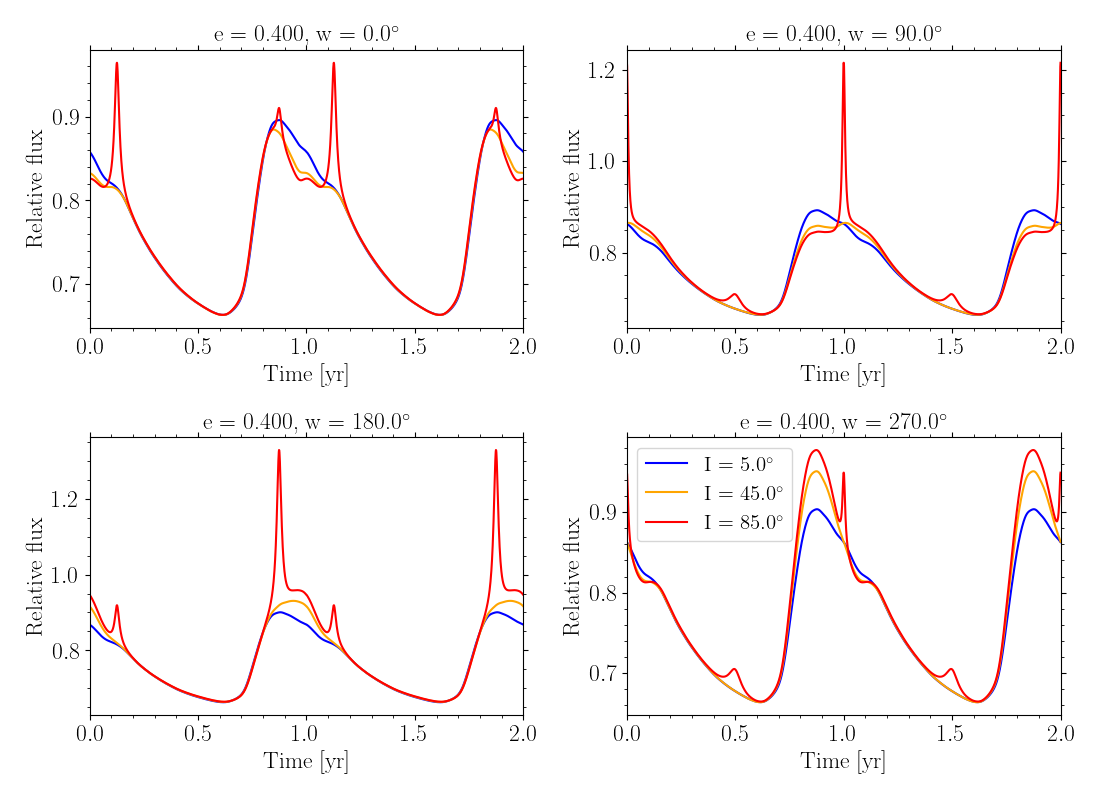

In [192]:
# Here we reproduce Fig. 6, including the accretion modulation
fig, axes = plt.subplots(2, 2, figsize=(11,8))
for w_deg,ax in zip(omegas_deg, [axes[0,0], axes[0,1], axes[1,0], axes[1,1]]):
    for I_deg,c,l in zip(inclinations_deg, colors, labels):
        acc = AccretionSeries(e, n_modes=29, n_orbits=n_orbits, retrograde=False)
        bad = BinaryAlphaDisk(e, T_yr, M_msun, dl_pc, eddington_ratio=f_edd, retrograde=False, 
                             argument_of_pericenter_deg=w_deg, inclination_deg=I_deg)
        flux_lb = blt.flux.normalized_flux_series_from_bad(frequency, acc, bad, lens_boost=True)
        yrs = blt.flux.time_from_bad(acc, bad)
        ax.plot(yrs, flux_lb, '-', c=c, label=f'I = {I_deg:.1f}'+r'$^{\circ}$')
    ax.set_xlim(0, yrs[-1])
    ax.set_xlabel(r"Time [yr]")
    ax.set_ylabel(r"Relative flux")
    ax.set_title(f'e = {e:.3f}, w = {w_deg:.1f}'+r'$^{\circ}$')
plt.legend()
plt.tight_layout();
# fig.savefig(fdir / f'model_comparison_dorazio+2024fig6.png', bbox_inches='tight', dpi=300)

<IPython.core.display.Javascript object>


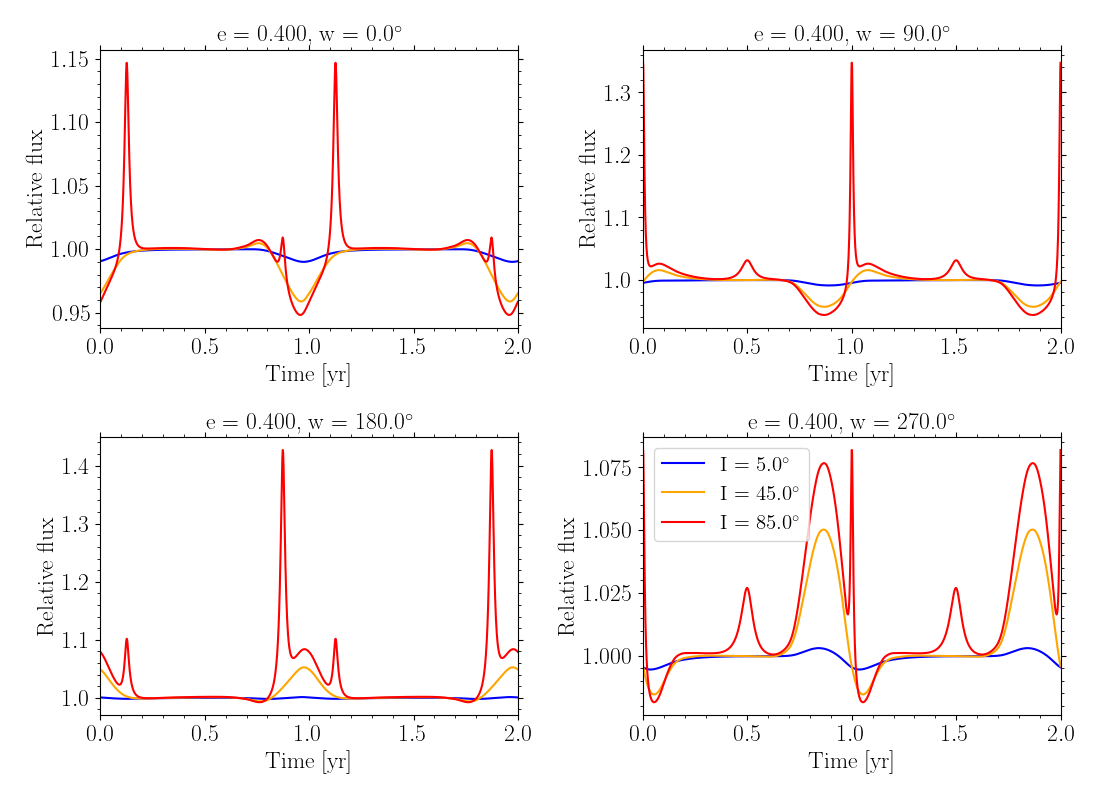

In [193]:
# Here we only look at the lensing + boosting signal
fig, axes = plt.subplots(2, 2, figsize=(11,8))
for w_deg,ax in zip(omegas_deg, [axes[0,0], axes[0,1], axes[1,0], axes[1,1]]):
    for I_deg,c,l in zip(inclinations_deg, colors, labels):
        acc = AccretionSeries(e, n_modes=29, n_orbits=n_orbits, retrograde=False)
        bad = BinaryAlphaDisk(e, T_yr, M_msun, dl_pc, eddington_ratio=f_edd, retrograde=False, 
                             argument_of_pericenter_deg=w_deg, inclination_deg=I_deg)
        flux_lb = blt.flux.normalized_flux_series_from_bad(frequency, acc, bad, lens_boost=True)
        flux_no = blt.flux.normalized_flux_series_from_bad(frequency, acc, bad, lens_boost=False)
        yrs = blt.flux.time_from_bad(acc, bad)
        ax.plot(yrs, flux_lb-flux_no+1, '-', c=c, label=f'I = {I_deg:.1f}'+r'$^{\circ}$')
    ax.set_xlim(0, yrs[-1])
    ax.set_xlabel(r"Time [yr]")
    ax.set_ylabel(r"Relative flux")
    ax.set_title(f'e = {e:.3f}, w = {w_deg:.1f}'+r'$^{\circ}$')
plt.legend()
plt.tight_layout();
# fig.savefig(fdir / f'model_comparison_dorazio2024fig6_no_accretion.png', bbox_inches='tight', dpi=300)

### Compare my code with Binlite

In [264]:
eccentricities = [0.001, 0.234, 0.467, 0.7]
omegas_deg = [0, 90, 180, 270]
colors = ['orange', 'deeppink', 'purple', 'navy']

<IPython.core.display.Javascript object>


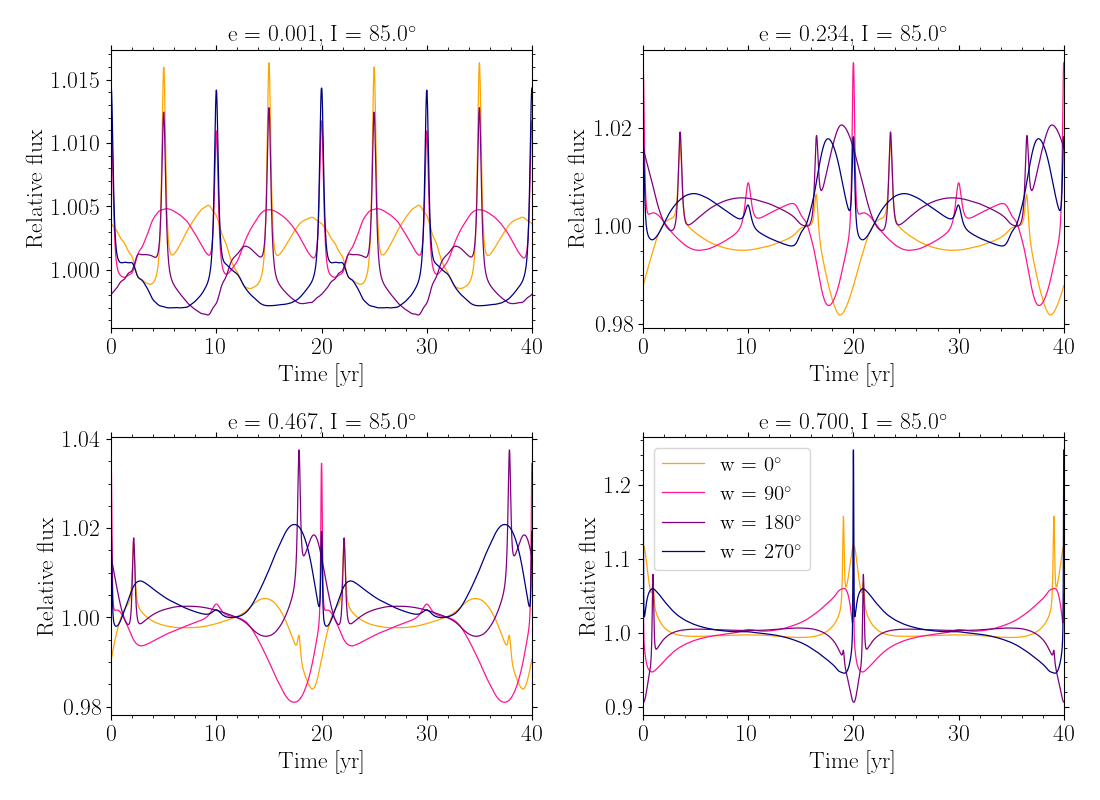

In [266]:
# Parameters stated in Section 4 (Example Lightcurves)
n_orbits = 2
P_yr = 20
M_msun = 5e8 + 5e7
f_edd = 0.1
dl_pc = 1.5 * 1e9  # z~0.29
I_deg = 85 

# Here we only look at the lensing + boosting signal
fig, axes = plt.subplots(2, 2, figsize=(11,8))
for e,ax in zip(eccentricities, [axes[0,0], axes[0,1], axes[1,0], axes[1,1]]):
    for w_deg,c,l in zip(omegas_deg, colors, labels):
        acc = AccretionSeries(e, n_modes=29, n_orbits=n_orbits, retrograde=False)
        bad = BinaryAlphaDisk(e, P_yr, M_msun, dl_pc, eddington_ratio=f_edd, retrograde=False, 
                             argument_of_pericenter_deg=w_deg, inclination_deg=I_deg)
        flux_lb = blt.flux.normalized_flux_series_from_bad(frequency, acc, bad, lens_boost=True)
        flux_no = blt.flux.normalized_flux_series_from_bad(frequency, acc, bad, lens_boost=False)
        yrs = blt.flux.time_from_bad(acc, bad)
        ax.plot(yrs, flux_lb-flux_no+1, '-', c=c, lw=0.9, label=f'w = {w_deg:.0f}'+r'$^{\circ}$')
    ax.set_xlim(0, yrs[-1])
    ax.set_xlabel(r"Time [yr]")
    ax.set_ylabel(r"Relative flux")
    ax.set_title(f'e = {e:.3f}, I = {I_deg:.1f}'+r'$^{\circ}$')
plt.legend()
plt.tight_layout();

<IPython.core.display.Javascript object>


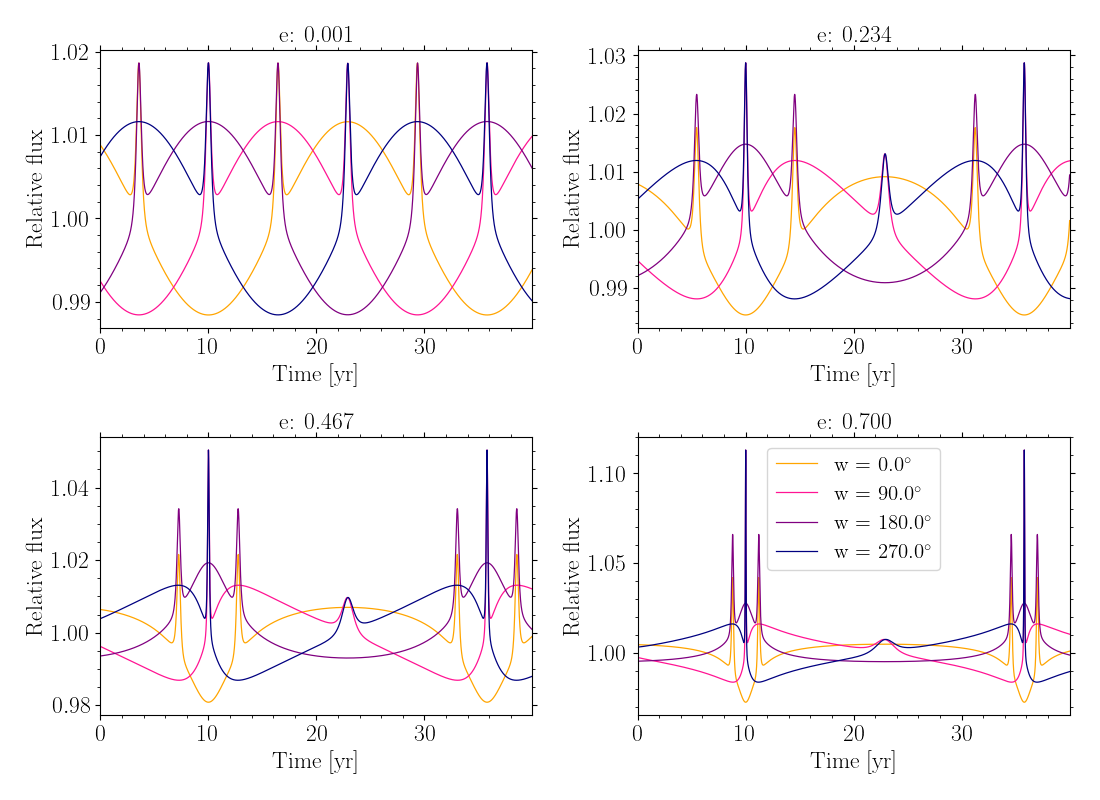

In [268]:
# Initialise model
dt   = 3600
tdur = ut.year() * 40
time = np.arange(0, tdur, dt) * u.s
model = SMBHB(time, seed=123456789)

# Parameters
t0 = 10 * u.yr
P = 20 * u.yr
M1 = (5e7 + 5e8)/2 * u.M_sun
M2 = (5e7 + 5e8)/2 * u.M_sun
i = np.deg2rad(85) * u.rad
L = 1
z = 0.29
alpha = 2.0
v_z   = 0
J = np.pi/2 * u.rad

fig, axes = plt.subplots(2, 2, figsize=(11,8))
for e,ax in zip(eccentricities, [axes[0,0], axes[0,1], axes[1,0], axes[1,1]]):
    t = (time / 86400 / 365.25).value
    for w_deg,c,l in zip(omegas_deg, colors, labels):
        w_rad = np.deg2rad(w_deg) * u.rad
        model.initPhysicalModel(t0, z, P, M1, M2, i, e, w_rad, L)
        model.doppler_boosting(alpha, v_z)
        model.gravitational_lensing(J, wvl)
        flux = model.evalPhysicalModel()
        ax.plot(t, flux, '-', c=c, lw=0.9, label=f'w = {w_deg:.1f}'+r'$^{\circ}$')
    ax.set_xlim(0, t[-1])
    ax.set_xlabel(r"Time [yr]")
    ax.set_ylabel(r"Relative flux")
    ax.set_title(f'e: {e:.3f}')
plt.legend()
plt.tight_layout();

In [364]:
# Initialise model
dt   = 3600
tdur = 3 * ut.year()
time = np.arange(0, tdur, dt) * u.s
    
flux = lensing_boosting_magnification(time)

Model parameters:
Redshift,                     z  : 0.962
Time of ephemeris,            t0 : 1.050 yr
Orbital period in rest frame, P  : 1.144 yr
Orbital period in obs. frame, T  : 2.245 yr
Mass of primary,              M1 : 25.119 solMass x 1e6
Mass of secondary,            M2 : 5.012 solMass x 1e6
Mass total,       (M1 + M2) = M  : 30.131 solMass x 1e6
Mass ratio,       (M2 / M1) = q  : 0.1995
Inclination to LOS,           i  : 81.95 deg
Eccentricity,                 e  : 0.52
Argument of periapse,         w  : 84.63 deg
Semi-major axis of binaries,  a  : 340.37 AU
Semi-major axis of primary,   a1 : 56.62 AU
Semi-major axis of secondary, a2 : 283.75 AU


NameError: name 'root_scalar' is not defined

In [351]:
np.rad2deg(np.arccos(0.140))

81.95215375268849

In [355]:
z  = 0.962
P  = 1.44
T  = P * (1+z)
T

2.82528